In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

PROJECT_DIR = Path(r"C:\Users\adaly\OneDrive\Documents\DMDeficientGalaxyTNG-1")
CATALOG = PROJECT_DIR / "data" / "dmdg_catalog_z0.csv"

df = pd.read_csv(CATALOG)
print(f"Total Catalog Objects: {len(df):,}")


Total Catalog Objects: 13,922,457


In [2]:
resolved = df[
    (df["N_star"] >= 500) &
    (df["SubhaloFlag"] == 1) &
    (df["f_DM"].notna())
].copy()

print(f"Resolved galaxies: {len(resolved):,}")

Resolved galaxies: 154,638


In [3]:

resolved["M_star_Msun"] = (
    resolved["M_star"] * 1e10 / 0.6774
)

mass_selected = resolved[
    (resolved["M_star_Msun"] > 1e9) &
    (resolved["M_star_Msun"] < 1e10)
].copy()
satellites = mass_selected[
    mass_selected["IsSatellite"] == True
].copy()
satellites["Host_M200c_Msun"] = (
    satellites["Host_M200c"] * 1e10 / 0.6774
)
group_selected = satellites[
    satellites["Host_M200c_Msun"] > 1e13
].copy()
dmdgs = group_selected[
    group_selected["f_DM"] < 0.5
].copy()
dmdgs_non_extreme = dmdgs[
   dmdgs["f_DM"] > 0.05
].copy()
print(f"DMDGS (non-tidal stripping): {len(dmdgs_non_extreme):,}")

DMDGS (non-tidal stripping): 400


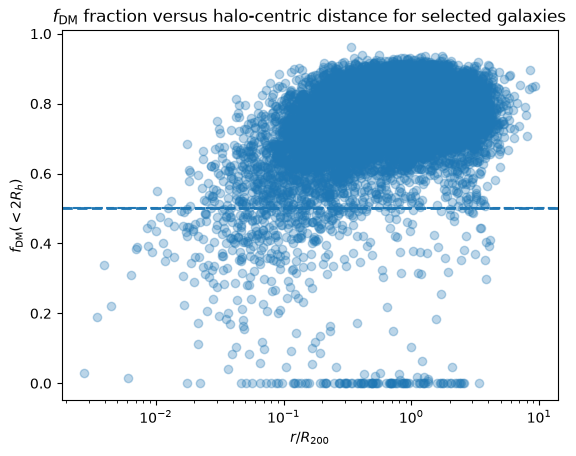

In [14]:
df = pd.DataFrame({'x-values': group_selected['r_over_R200c'], 'y_values': group_selected['f_DM']})
plt.plot(
   df["x-values"],
   df["y_values"],
   linestyle="none",
   marker='o',
   alpha = 0.3
)
plt.axhline(
    0.5,
    linestyle="--",
    linewidth=2,
    label=r"$f_{\rm DM}=0.5$"
)
plt.axhline(0.5, linestyle="--")
plt.xscale("log")
plt.title(r"$f_{\rm DM}$ fraction versus halo-centric distance for selected galaxies")
plt.ylabel(r"$f_{\rm DM}(<2R_h)$")
plt.xlabel(r"$r/R_{200}$")
plt.show()

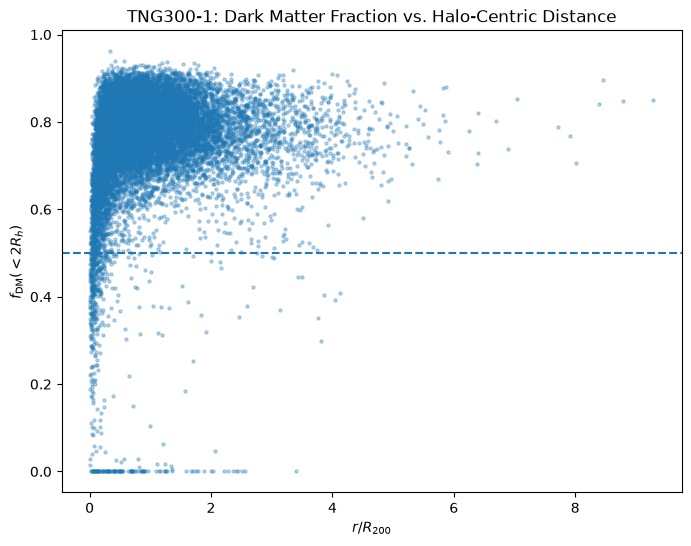

In [6]:
plt.figure(figsize=(8, 6))

plt.scatter(
    group_selected["r_over_R200c"],
    group_selected["f_DM"],
    s=5,
    alpha=0.3
)

plt.axhline(0.5, linestyle="--")

plt.xlabel(r"$r/R_{200}$")
plt.ylabel(r"$f_{\rm DM}(<2R_h)$")
plt.title("TNG300-1: Dark Matter Fraction vs. Halo-Centric Distance")

plt.show()